In [ ]:
!pip install pandas-gbq --quiet

In [ ]:
import pandas as pd
from pandas_gbq import read_gbq

In [ ]:
query = """
    SELECT *
    FROM bigquery-public-data.covid19_jhu_csse.confirmed_cases
    LIMIT 10
"""

df = read_gbq(query, project_id="crypto-meridian-468717-e8", location='US', dialect='standard', auth_local_webserver=False)

Downloading: 100%|██████████|


In [ ]:
df.head()

,province_or_state,country_or_region,latitude,longitude,location_geom,_1_22_20,_1_23_20,_1_24_20,_1_25_20,_1_26_20,...,_2_28_23,_3_1_23,_3_2_23,_3_3_23,_3_4_23,_3_5_23,_3_6_23,_3_7_23,_3_8_23,_3_9_23
0,None,Antarctica,-71.9499,23.347,POINT(-71.9499 23.347),0,0,0,0,0,...,11,11,11,11,11,11,11,11,11,11
1,Diamond Princess,Canada,0.0,0.0,POINT(0.0 0.0),0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,None,"Korea, North",40.3399,127.5101,POINT(40.3399 127.5101),0,0,0,0,0,...,1,1,1,1,1,1,1,1,1,1
3,None,Nauru,-0.5228,166.9315,POINT(-0.5228 166.9315),0,0,0,0,0,...,5247,5247,5247,5247,5247,5247,5247,5247,5247,5247
4,Niue,New Zealand,-19.0544,-169.8672,POINT(-19.0544 -169.8672),0,0,0,0,0,...,788,790,790,790,790,790,791,791,791,792


In [ ]:
df = df.dropna()
df = df.drop_duplicates()
df = df.fillna(0)

date_columns = [col for col in df.columns if col.startswith('_')]
formatted_date_columns = pd.to_datetime(date_columns, format='_%m_%d_%y', errors='coerce').strftime('%m-%d-%Y')

column_mapping = dict(zip(date_columns, formatted_date_columns))

df_formatted_cols = df.rename(columns=column_mapping)

display(df_formatted_cols.head())

print("Estatísticas descritivas para o DataFrame inicial (df):")
display(df.describe())

print("\nInformações para o DataFrame inicial (df):")
df.info()

print("\nEstatísticas descritivas para o DataFrame após limpeza inicial e renomeação (df_formatted_cols):")
display(df_formatted_cols.describe())

print("\nInformações para o DataFrame após limpeza inicial e renomeação (df_formatted_cols):")
df_formatted_cols.info()



,province_or_state,country_or_region,latitude,longitude,location_geom,01-22-2020,01-23-2020,01-24-2020,01-25-2020,01-26-2020,...,02-28-2023,03-01-2023,03-02-2023,03-03-2023,03-04-2023,03-05-2023,03-06-2023,03-07-2023,03-08-2023,03-09-2023
1,Diamond Princess,Canada,0.0,0.0,POINT(0.0 0.0),0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,Niue,New Zealand,-19.0544,-169.8672,POINT(-19.0544 -169.8672),0,0,0,0,0,...,788,790,790,790,790,790,791,791,791,792
9,Channel Islands,United Kingdom,49.3723,-2.3644,POINT(49.3723 -2.3644),0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Estatísticas descritivas para o DataFrame inicial (df):


,province_or_state,country_or_region,latitude,longitude,location_geom,_1_22_20,_1_23_20,_1_24_20,_1_25_20,_1_26_20,...,_2_28_23,_3_1_23,_3_2_23,_3_3_23,_3_4_23,_3_5_23,_3_6_23,_3_7_23,_3_8_23,_3_9_23
count,3,3,3,3,3,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3
unique,3,3,3,3,3,1,1,1,1,1,...,2,2,2,2,2,2,2,2,2,2
top,Diamond Princess,Canada,0.0,0.0,POINT(0.0 0.0),0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
freq,1,1,1,1,1,3,3,3,3,3,...,2,2,2,2,2,2,2,2,2,2



Informações para o DataFrame inicial (df):
<class 'pandas.core.frame.DataFrame'>
Index: 3 entries, 1 to 9
Columns: 1148 entries, province_or_state to _3_9_23
dtypes: object(1148)
memory usage: 26.9+ KB

Estatísticas descritivas para o DataFrame após limpeza inicial e renomeação (df_formatted_cols):


,province_or_state,country_or_region,latitude,longitude,location_geom,01-22-2020,01-23-2020,01-24-2020,01-25-2020,01-26-2020,...,02-28-2023,03-01-2023,03-02-2023,03-03-2023,03-04-2023,03-05-2023,03-06-2023,03-07-2023,03-08-2023,03-09-2023
count,3,3,3,3,3,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3
unique,3,3,3,3,3,1,1,1,1,1,...,2,2,2,2,2,2,2,2,2,2
top,Diamond Princess,Canada,0.0,0.0,POINT(0.0 0.0),0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
freq,1,1,1,1,1,3,3,3,3,3,...,2,2,2,2,2,2,2,2,2,2



Informações para o DataFrame após limpeza inicial e renomeação (df_formatted_cols):
<class 'pandas.core.frame.DataFrame'>
Index: 3 entries, 1 to 9
Columns: 1148 entries, province_or_state to 03-09-2023
dtypes: object(1148)
memory usage: 26.9+ KB


# **Qual é o total de casos confirmados por país na data mais recente disponível no conjunto de dados, mostrando apenas os países com mais de 100 casos?**

In [ ]:
# Encontrar a coluna da data mais recente
latest_date_column = df_formatted_cols.columns[-1]

# Converter a coluna da data mais recente para numérico, tratando erros
df_formatted_cols[latest_date_column] = pd.to_numeric(df_formatted_cols[latest_date_column], errors='coerce')

# Agrupar por país e obter o total de casos confirmados na data mais recente
total_cases_by_country_latest_date = df_formatted_cols.groupby('country_or_region')[latest_date_column].sum().reset_index()

# Filtrar para mostrar apenas países com mais de 100 casos na data mais recente
countries_with_high_cases_latest = total_cases_by_country_latest_date[total_cases_by_country_latest_date[latest_date_column] > 100]

# Renomear a coluna da data mais recente para maior clareza no resultado
countries_with_high_cases_latest = countries_with_high_cases_latest.rename(columns={latest_date_column: 'Total Confirmed Cases on Latest Date'})

# Exibir o resultado
display(countries_with_high_cases_latest)

,country_or_region,Total Confirmed Cases on Latest Date
1,New Zealand,792


# **Qual é a tendência de casos confirmados ao longo do tempo para os 5 principais países com o maior número total de casos confirmados?**

In [ ]:
# Derreter o DataFrame para o formato longo
df_melted = df_formatted_cols.melt(
    id_vars=['province_or_state', 'country_or_region', 'latitude', 'longitude', 'location_geom'],
    var_name='date',
    value_name='confirmed_cases'
)

# Converter a coluna 'date' para objetos datetime
df_melted['date'] = pd.to_datetime(df_melted['date'], format='%m-%d-%Y', errors='coerce')

# Converter 'confirmed_cases' para numérico, tratando erros
df_melted['confirmed_cases'] = pd.to_numeric(df_melted['confirmed_cases'], errors='coerce')

# Agrupar por país e data, e somar os casos confirmados
df_grouped_by_date = df_melted.groupby(['country_or_region', 'date'])['confirmed_cases'].sum().reset_index()

# Obter os 5 principais países com o maior número total de casos confirmados
total_cases_by_country = df_grouped_by_date.groupby('country_or_region')['confirmed_cases'].sum().reset_index()
top_5_countries = total_cases_by_country.nlargest(5, 'confirmed_cases')['country_or_region'].tolist()

# Filtrar os dados agrupados para os 5 principais países
df_top_5_countries = df_grouped_by_date[df_grouped_by_date['country_or_region'].isin(top_5_countries)]

# Classificar por data para plotagem
df_top_5_countries = df_top_5_countries.sort_values(by='date')

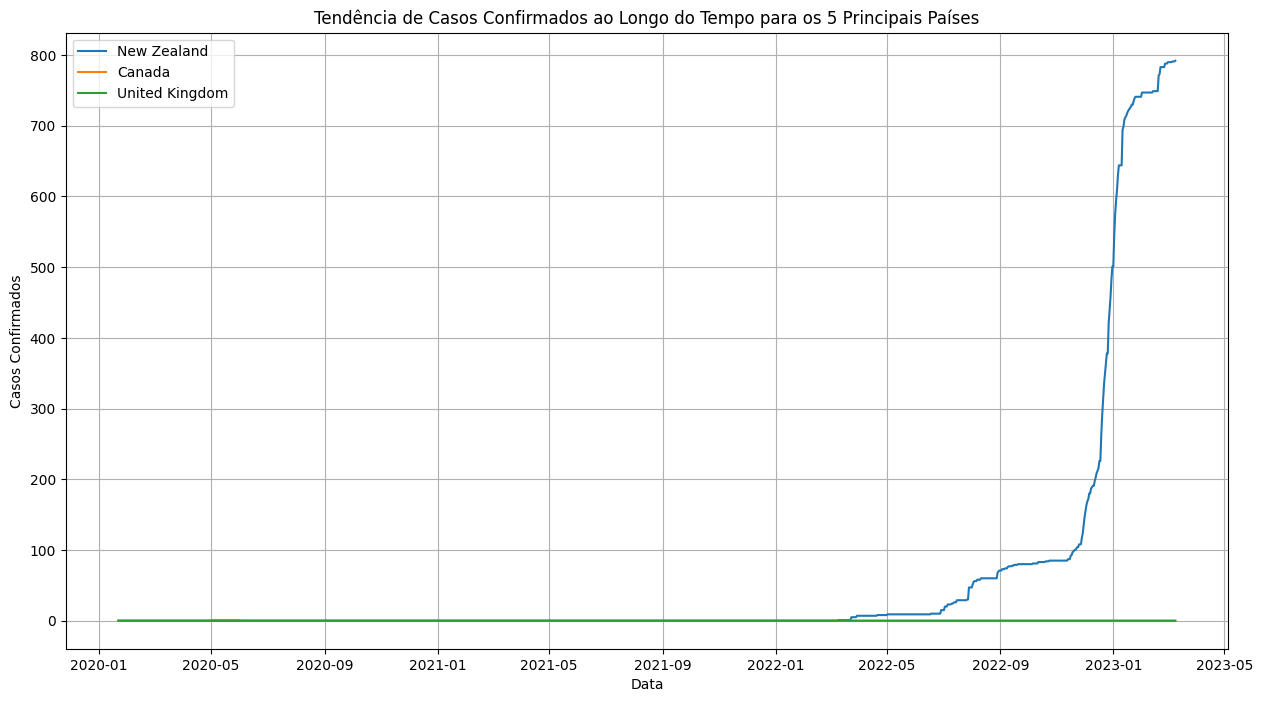

In [ ]:
import matplotlib.pyplot as plt

# Plotar os casos confirmados ao longo do tempo para os 5 principais países
plt.figure(figsize=(15, 8))
for country in top_5_countries:
    country_data = df_top_5_countries[df_top_5_countries['country_or_region'] == country]
    plt.plot(country_data['date'], country_data['confirmed_cases'], label=country)

plt.xlabel('Data')
plt.ylabel('Casos Confirmados')
plt.title('Tendência de Casos Confirmados ao Longo do Tempo para os 5 Principais Países')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
Com base na análise realizada, as principais descobertas e insights são:

Total de Casos Confirmados por País na Data Mais Recente: Na data mais recente disponível no conjunto de dados (09/03/2023), apenas a Nova Zelândia apresentou mais de 100 casos confirmados (792 casos).
Tendência de Casos Confirmados ao Longo do Tempo: A Nova Zelândia mostrou um aumento significativo no número de casos confirmados ao longo do tempo, especialmente a partir do final de 2022. Canadá e Reino Unido,
por outro lado, mantiveram um número baixo ou zero de casos confirmados no período analisado.